In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

class0 = np.random.randn(25, 2) * 0.8 + np.array([2, 2])
labels0 = np.zeros(25)

class1 = np.random.randn(25, 2) * 0.8 + np.array([-2, -2])
labels1 = np.ones(25)

outlier = np.array([[10, 10]])
outlier_label = np.array([0])

X = np.vstack([class0, class1, outlier])
t = np.hstack([labels0, labels1, outlier_label])

N = X.shape[0]

In [2]:
phi = np.hstack([np.ones((N, 1)), X])

In [3]:
def sigmoid(a):
    return 1 / (1 + np.exp(-a))

In [4]:
eta = 0.1
iterations = 1000

w = np.zeros(3)

for _ in range(iterations):
    a = phi @ w
    y = sigmoid(a)
    gradient = phi.T @ (y - t)
    w = w - eta * gradient

print("Learned weights:", w)

Learned weights: [-0.05210083 -5.41677489 -5.10708769]


In [5]:
x1_vals = np.linspace(-5, 12, 200)
x2_vals = -(w[0] + w[1] * x1_vals) / w[2]

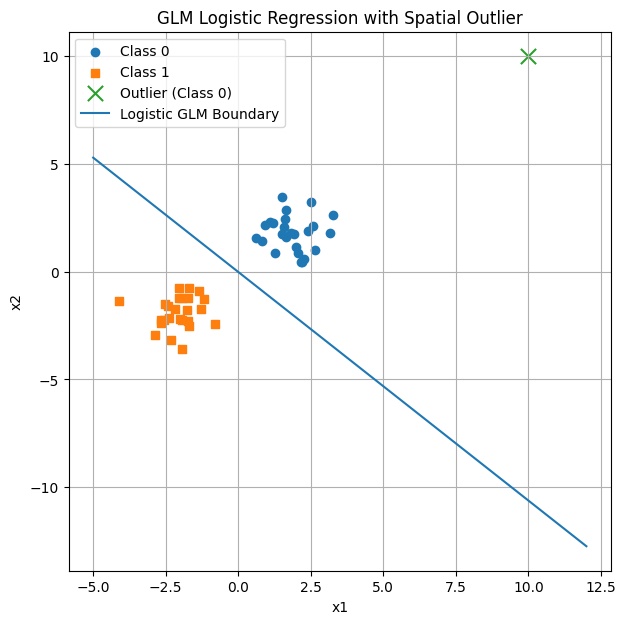

In [6]:
plt.figure(figsize=(7,7))

plt.scatter(class0[:,0], class0[:,1], label="Class 0", marker='o')

plt.scatter(class1[:,0], class1[:,1], label="Class 1", marker='s')

plt.scatter(outlier[:,0], outlier[:,1], label="Outlier (Class 0)", marker='x', s=120)

plt.plot(x1_vals, x2_vals, label="Logistic GLM Boundary")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("GLM Logistic Regression with Spatial Outlier")
plt.legend()
plt.grid(True)
plt.show()